Import libraries

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import math

read train images

In [22]:
trainImages_path = "data/train/train-images.idx3-ubyte"
trainImage_file = open(trainImages_path, "rb")
trainImageData = trainImage_file.read()
trainImage_header = trainImageData[:16]
trainImages = trainImageData[16:]

read train labels

In [23]:
trainLabels_path = "data/train/train-labels.idx1-ubyte"
trainLabels_file = open(trainLabels_path, "rb")
trainLabelsData = trainLabels_file.read()
trainLabels_header = trainLabelsData[:8]
trainLabels = trainLabelsData[8:]

read header

In [24]:
magic_number = int.from_bytes(trainImage_header[0:4], byteorder='big')
image_count = int.from_bytes(trainImage_header[4:8], byteorder='big')
row_count = int.from_bytes(trainImage_header[8:12], byteorder='big')
col_count = int.from_bytes(trainImage_header[12:16], byteorder='big')
print(magic_number, image_count, row_count, col_count)

2051 60000 28 28


split data to array for per image

In [25]:
images_array = np.frombuffer(trainImages, dtype=np.uint8).copy()

images_flattened = images_array.reshape(-1, 28*28)

images_2d = images_array.reshape(-1, 28, 28)

show top 5 images and labels

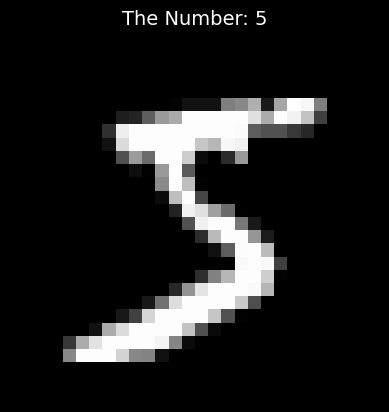

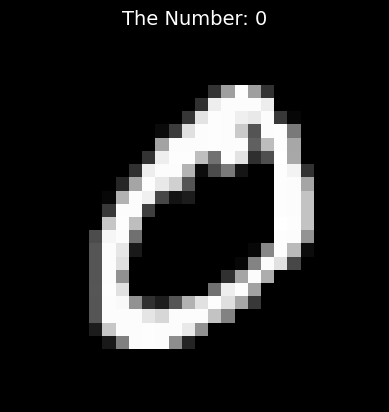

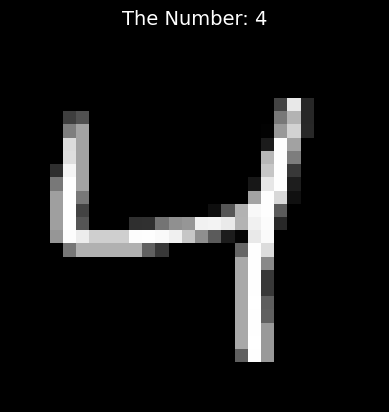

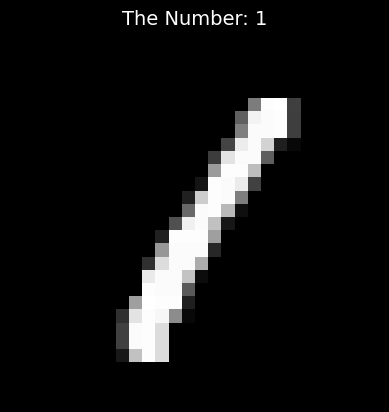

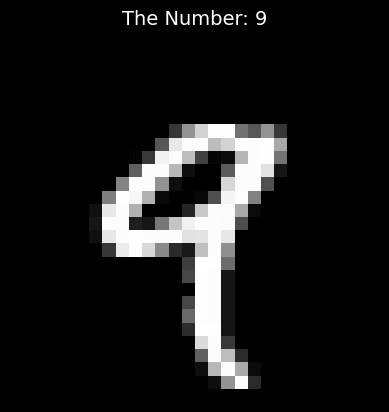

In [26]:
for i in range(5):
    image_matrices = np.array(list(images_2d[i])).reshape(28, 28)
    plt.imshow(image_matrices, cmap='gray')
    plt.title("The Number: " + str(trainLabels[i]), fontsize=14)
    plt.axis('off')
    plt.show()

Initiliaze weights

In [27]:
weights_e = np.random.randn(784, 256) * 0.01
bias_e = np.zeros((1, 256))

weights_bottleneckIn = np.random.randn(256, 64) * 0.01
bias_bottleneckIn = np.zeros((1, 64))

weights_bottleneckOut = np.random.randn(64, 256) * 0.01
bias_bottleneckOut = np.zeros((1, 256))

weights_d  = np.random.randn(256, 784) * 0.01
bias_d = np.zeros((1, 784))

Activation functions

In [28]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    x_clipped = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x_clipped))

def sigmoid_derivative(x):
    sig = sigmoid(x)
    return sig * (1 - sig)

Parameters

In [29]:
learning_rate = 0.1
epoch = 20
batch_size = 64

Training

In [30]:
for epoch in range(epoch):
    np.random.shuffle(images_flattened)
    epoch_loss = 0

    for i in range(0, image_count, batch_size):

        mini_batch = images_flattened[i:i+batch_size] /255.0

        current_batch_size = len(mini_batch)

        # forward
        forward_encoder = np.dot(mini_batch, weights_e) + bias_e
        activation_encoder = relu(forward_encoder)

        forward_btIn = np.dot(activation_encoder, weights_bottleneckIn) + bias_bottleneckIn
        activation_bottleneckIn = relu(forward_btIn)

        forward_btOut = np.dot(activation_bottleneckIn, weights_bottleneckOut) + bias_bottleneckOut
        activation_bottleneckOut = relu(forward_btOut)

        forward_decoder = np.dot(activation_bottleneckOut, weights_d) + bias_d
        activation_decoder = sigmoid(forward_decoder)

        batch_loss = np.mean(np.square(mini_batch - activation_decoder))
        epoch_loss += batch_loss * current_batch_size

        d_forward_decoder = ((activation_decoder - mini_batch) * sigmoid_derivative(forward_decoder)) / current_batch_size
        d_weights_d = np.dot(activation_bottleneckOut.T, d_forward_decoder)
        d_bias_d = np.sum(d_forward_decoder, axis=0, keepdims=True)


        d_activation_bottleneckOut = np.dot(d_forward_decoder, weights_d.T)
        d_forward_btOut = d_activation_bottleneckOut * relu_derivative(forward_btOut)
        d_weights_bottleneckOut = np.dot(activation_bottleneckIn.T, d_forward_btOut)
        d_bias_bottleneckOut = np.sum(d_forward_btOut, axis=0, keepdims=True)


        d_activation_bottleneckIn = np.dot(d_forward_btOut, weights_bottleneckOut.T)
        d_forward_btIn = d_activation_bottleneckIn * relu_derivative(forward_btIn)
        d_weights_bottleneckIn = np.dot(activation_encoder.T, d_forward_btIn)
        d_bias_bottleneckIn = np.sum(d_forward_btIn, axis=0, keepdims=True)


        d_activation_encoder = np.dot(d_forward_btIn, weights_bottleneckIn.T)
        d_forward_encoder = d_activation_encoder * relu_derivative(forward_encoder)
        d_weights_e = np.dot(mini_batch.T, d_forward_encoder)
        d_bias_e = np.sum(d_forward_encoder, axis=0, keepdims=True)


        weights_d -= learning_rate * d_weights_d
        bias_d -= learning_rate * d_bias_d

        weights_bottleneckOut -= learning_rate * d_weights_bottleneckOut
        bias_bottleneckOut -= learning_rate * d_bias_bottleneckOut

        weights_bottleneckIn -= learning_rate * d_weights_bottleneckIn
        bias_bottleneckIn -= learning_rate * d_bias_bottleneckIn

        weights_e -= learning_rate * d_weights_e
        bias_e -= learning_rate * d_bias_e

    ort_hata = epoch_loss / image_count
    print(f"tamamlandı. Ortalama Hata: {ort_hata:.5f}")

tamamlandı. Ortalama Hata: 0.05793
tamamlandı. Ortalama Hata: 0.02924
tamamlandı. Ortalama Hata: 0.01900
tamamlandı. Ortalama Hata: 0.01458
tamamlandı. Ortalama Hata: 0.01213
tamamlandı. Ortalama Hata: 0.01065
tamamlandı. Ortalama Hata: 0.00969
tamamlandı. Ortalama Hata: 0.00896
tamamlandı. Ortalama Hata: 0.00843
tamamlandı. Ortalama Hata: 0.00800
tamamlandı. Ortalama Hata: 0.00760
tamamlandı. Ortalama Hata: 0.00731
tamamlandı. Ortalama Hata: 0.00704
tamamlandı. Ortalama Hata: 0.00679
tamamlandı. Ortalama Hata: 0.00663
tamamlandı. Ortalama Hata: 0.00642
tamamlandı. Ortalama Hata: 0.00627
tamamlandı. Ortalama Hata: 0.00612
tamamlandı. Ortalama Hata: 0.00597
tamamlandı. Ortalama Hata: 0.00585


get test images

In [36]:
testImages_path = "data/test/t10k-images.idx3-ubyte"
testImage_file = open(testImages_path, "rb")
testImageData = testImage_file.read()
testImage_header = testImageData[:16]
testImages = testImageData[16:]

test_images_array = np.frombuffer(testImages, dtype=np.uint8).copy()

test_images_flattened = test_images_array.reshape(-1, 28*28)

Test reconstruction

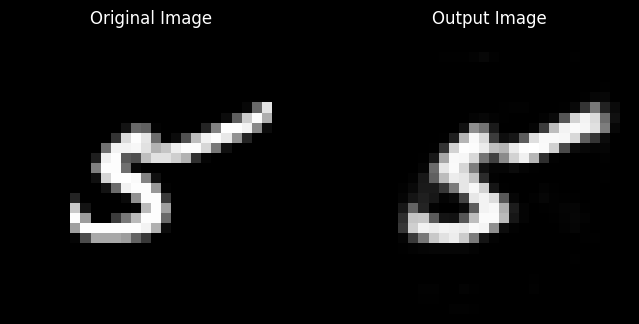

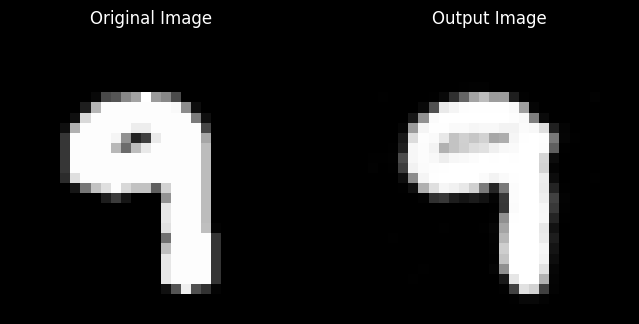

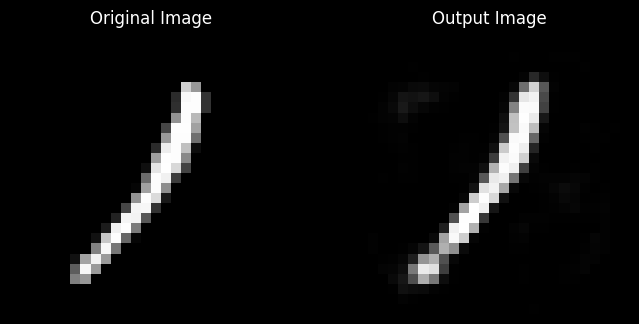

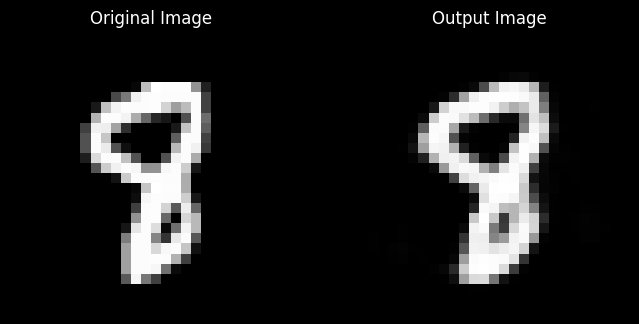

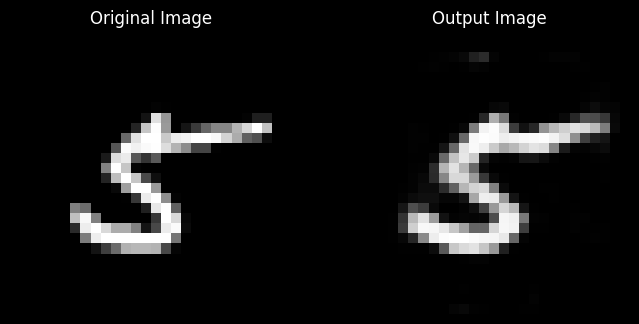

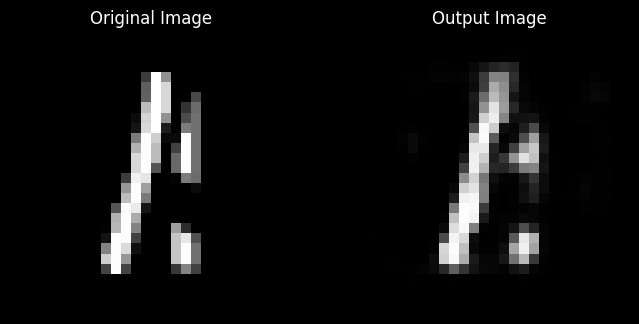

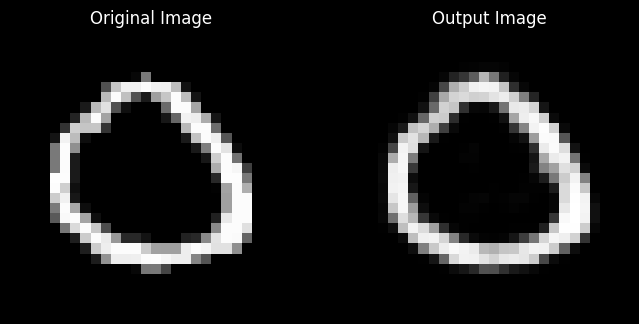

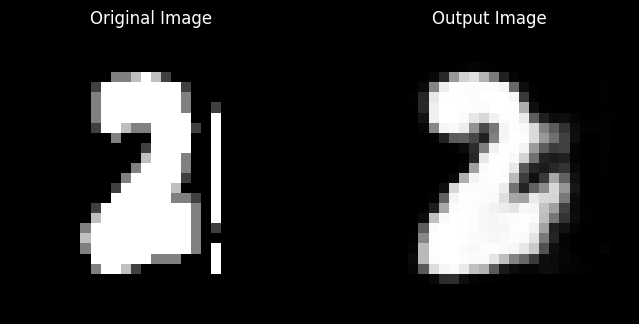

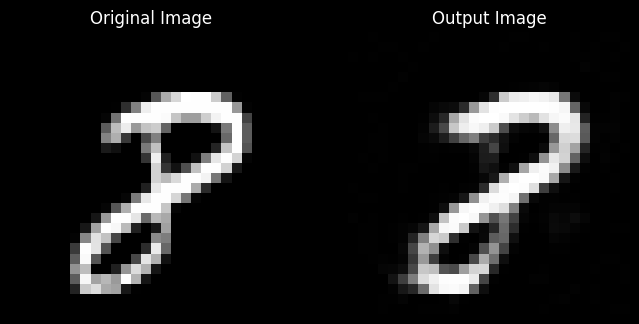

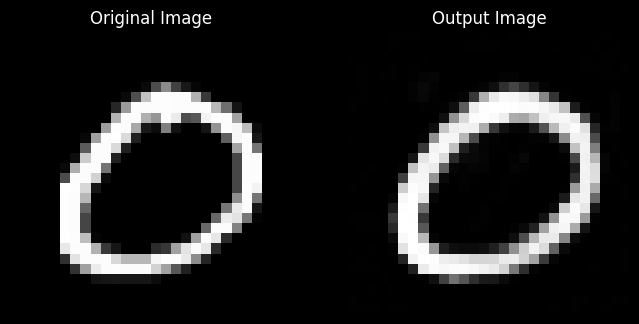

In [38]:
for i in range(10):
    test_index = np.random.randint(0, 10000 - 1)
    original_image = test_images_flattened[test_index].reshape(1, 784) / 255.0

    test_z1 = np.dot(original_image, weights_e) + bias_e
    test_a1 = relu(test_z1)

    test_z2 = np.dot(test_a1, weights_bottleneckIn) + bias_bottleneckIn
    test_a2 = relu(test_z2)

    test_z3 = np.dot(test_a2, weights_bottleneckOut) + bias_bottleneckOut
    test_a3 = relu(test_z3)

    test_z4 = np.dot(test_a3, weights_d) + bias_d
    output_image = sigmoid(test_z4)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(original_image.reshape(28, 28), cmap='gray')
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(output_image.reshape(28, 28), cmap='gray')
    axes[1].set_title(f"Output Image")
    axes[1].axis('off')

    plt.show()